# Chapter 9: Signal Analysis - Construction of a causal, minimum-phase signal for a given amplitude spectrum

Daniel Koehn

Kiel, July 3rd 2026

In [1]:
# Import Python libraries 
# -----------------------
#%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import hilbert

Define spike time series ...

In [2]:
# Define parameters
dt = 1.                 # time sampling [s]
L = 800.                # length of the time series [s]

# Define time array
t = np.arange(0,L+dt,dt) # compute time vector
N = len(t)

#  Add spike impulse to time series x ...
x = np.zeros(N)
x[N//2] = 1.

Compute FFT of time series and compute amplitude spectrum ...

In [3]:
# Fourier transform
X = np.fft.fft(x)

# Compute amplitude spectrum
X_amp = np.abs(X)

Compute phase spectrum from the amplitude spectrum using the Hilbert transform ...

In [4]:
phi = hilbert(np.log(X_amp))

Assemble new signal in frequency domain

In [5]:
X_new = X_amp * np.exp(1j*phi)

Inverse Fourier transform new signal and compare it with the original signal

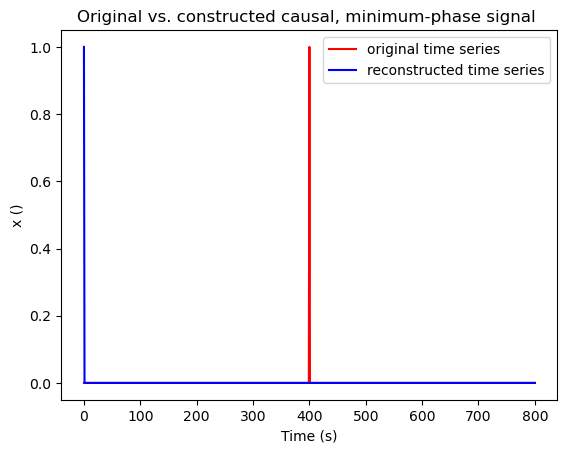

In [6]:
# Inverse Fourier transform
x_new = np.fft.ifft(X_new)

# Compare original with new signal
plt.plot(t, x, 'r', label='original time series')
plt.plot(t, np.real(x_new), 'b', label='reconstructed time series')
plt.xlabel('Time (s)')
plt.ylabel('x ()')
plt.title('Original vs. constructed causal, minimum-phase signal ')
plt.legend();